In [183]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt

products = pd.read_csv(Path("data", "products.csv"))
sales = pd.read_csv(Path("data", "sales.csv"))

#### Cleaning and Summary
 - Start by checking the correctness of the dataset and building a summary oriented towards answering the given questions.

In [184]:
products.head()

,product_id,name,category,price_sale,cost_unit,actual_stock
0,P001,Cafe molido 500g,Alimentos,8.5,5.1,45
1,P002,Te verde caja 20u,Alimentos,4.2,2.5,60
2,P003,Galletas avena,Alimentos,3.0,1.8,120
3,P004,Chocolate negro 70%,Alimentos,5.5,3.3,80
4,P005,Taza ceramica,Hogar,7.9,7.0,150


In [185]:
sales.head()

,id_venta,date,product_id,amount,discount_pct
0,V001,2026-05-01,P001,3,0
1,V002,2026-05-02,P005,6,10
2,V003,2026-05-02,P009,10,0
3,V004,2026-05-03,P003,4,0
4,V005,2026-05-04,P005,8,15


In [186]:
products.shape

(12, 6)

In [187]:
sales.shape

(20, 5)

In [188]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    12 non-null     str    
 1   name          12 non-null     str    
 2   category      12 non-null     str    
 3   price_sale    12 non-null     float64
 4   cost_unit     12 non-null     float64
 5   actual_stock  12 non-null     int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 708.0 bytes


In [189]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id_venta      20 non-null     str  
 1   date          20 non-null     str  
 2   product_id    20 non-null     str  
 3   amount        20 non-null     int64
 4   discount_pct  20 non-null     int64
dtypes: int64(2), str(3)
memory usage: 932.0 bytes


In [190]:
print(f'Products:\n\n{products.isna().sum()}')
print(f'- -' * 10)
print(f'Sales:\n\n{sales.isna().sum()}')

Products:

product_id      0
name            0
category        0
price_sale      0
cost_unit       0
actual_stock    0
dtype: int64
- -- -- -- -- -- -- -- -- -- -
Sales:

id_venta        0
date            0
product_id      0
amount          0
discount_pct    0
dtype: int64


In [191]:
sales["date"] = pd.to_datetime(sales["date"], format="%Y-%m-%d")

sales.dtypes

id_venta                   str
date            datetime64[us]
product_id                 str
amount                   int64
discount_pct             int64
dtype: object

In [192]:
print(f'Duplicated:\n\n{sales.duplicated().sum()}')
print(f'- -' * 10)
print(f'Duplicated:\n\n{products.duplicated().sum()}')

Duplicated:

0
- -- -- -- -- -- -- -- -- -- -
Duplicated:

0


#### Once cleaned start the summaries

In [193]:
sales_summary = (
    sales.merge(products[["product_id", "name", "price_sale", "cost_unit"]], on="product_id", how="left")
    .assign(profit=lambda d: d["amount"] * (d["price_sale"] * (1 - d["discount_pct"] / 100) - d["cost_unit"]))
)

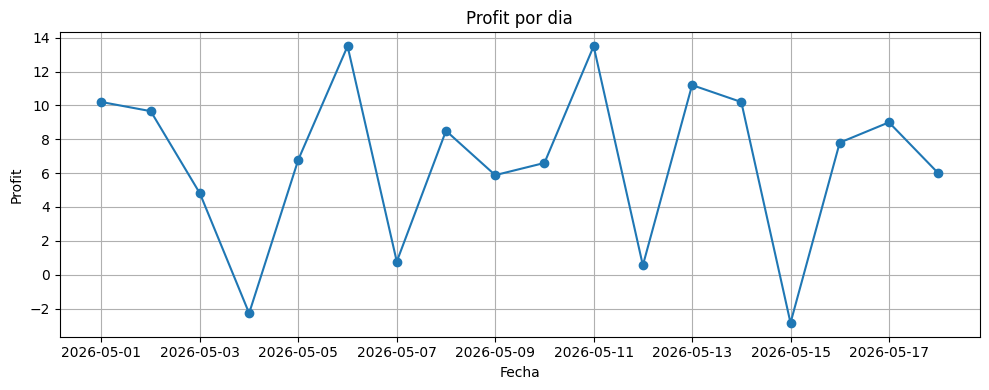

In [194]:
daily_profit = sales_summary.groupby("date")["profit"].sum()

plt.figure(figsize=(10, 4))
plt.plot(daily_profit.index, daily_profit.values, marker="o")
plt.title("Profit por dia")
plt.xlabel("Fecha")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/profit_per_day.pdf")
plt.show()

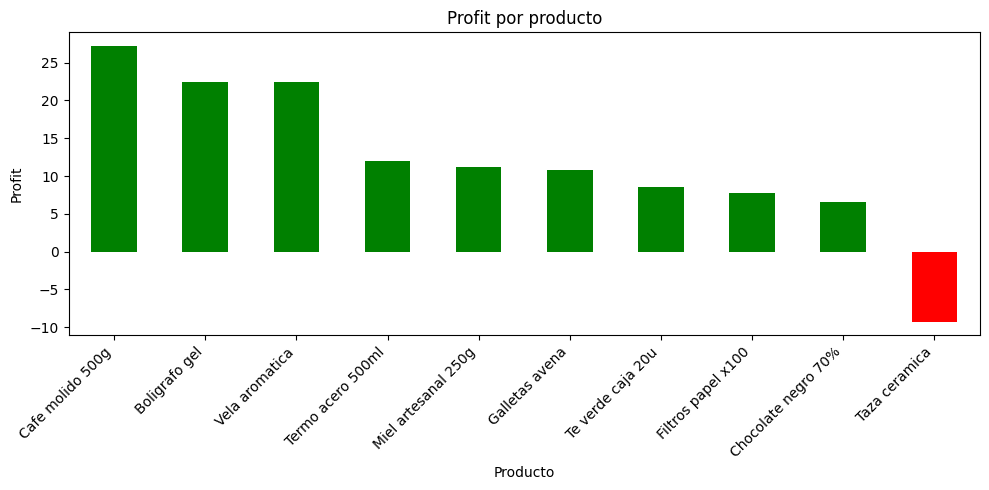

In [195]:
summary_by_product = sales_summary.groupby("name")["profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['green' if p >= 0 else 'red' for p in summary_by_product]
summary_by_product.plot(kind='bar', color=colors)
plt.ylabel('Profit')
plt.xlabel('Producto')
plt.title('Profit por producto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Figures/profit_per_product.pdf")
plt.show()